In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"

In [2]:
import sys
sys.path.append('../')

import superstats as sup
import bayesflow as bf

import numpy as np

INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
E0610 12:43:09.753107 1350373 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]
E0610 12:43:09.753273 1350375 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]
E0610 12:43:09.753310 1350374 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]
INFO:bayesflow:Using backend 'jax'


In [3]:
import jax
print(jax.devices())


[CudaDevice(id=0)]


- Proper defaults for all priors
- Discuss best practice for defaults
    + e.g. plotting
    + what about default and then check if none and set default

## Specify Prior

In [4]:
joint_prior = sup.prior.JointPrior(
    v = sup.transition.RandomWalk(
            bounds=(0.0, 6.0),
            sigma=sup.prior.Prior(dist="halfnormal", scale=0.1),
            delta=sup.prior.Prior(dist="halfnormal", scale=0.02),
            initial_prior=sup.prior.Prior(dist="normal", low=0.0, high=2.0)
        ),
    a = sup.transition.Mixture(
        transitions=[
            sup.transition.AutoRegression(),
            sup.transition.Jump()
        ],
        mixture_weights=sup.prior.Prior(dist="dirichlet", alpha=[15.0, 1.5]),
        bounds=(0.0, 4.0)
    ),
    bias = 0.5,
    tau = sup.prior.Prior(dist="halfnormal", scale=0.15)
)

In [ ]:
p = joint_prior.plot_time_varying_prior()

In [ ]:
p = joint_prior.plot_time_invariant_prior(num_cols=3)

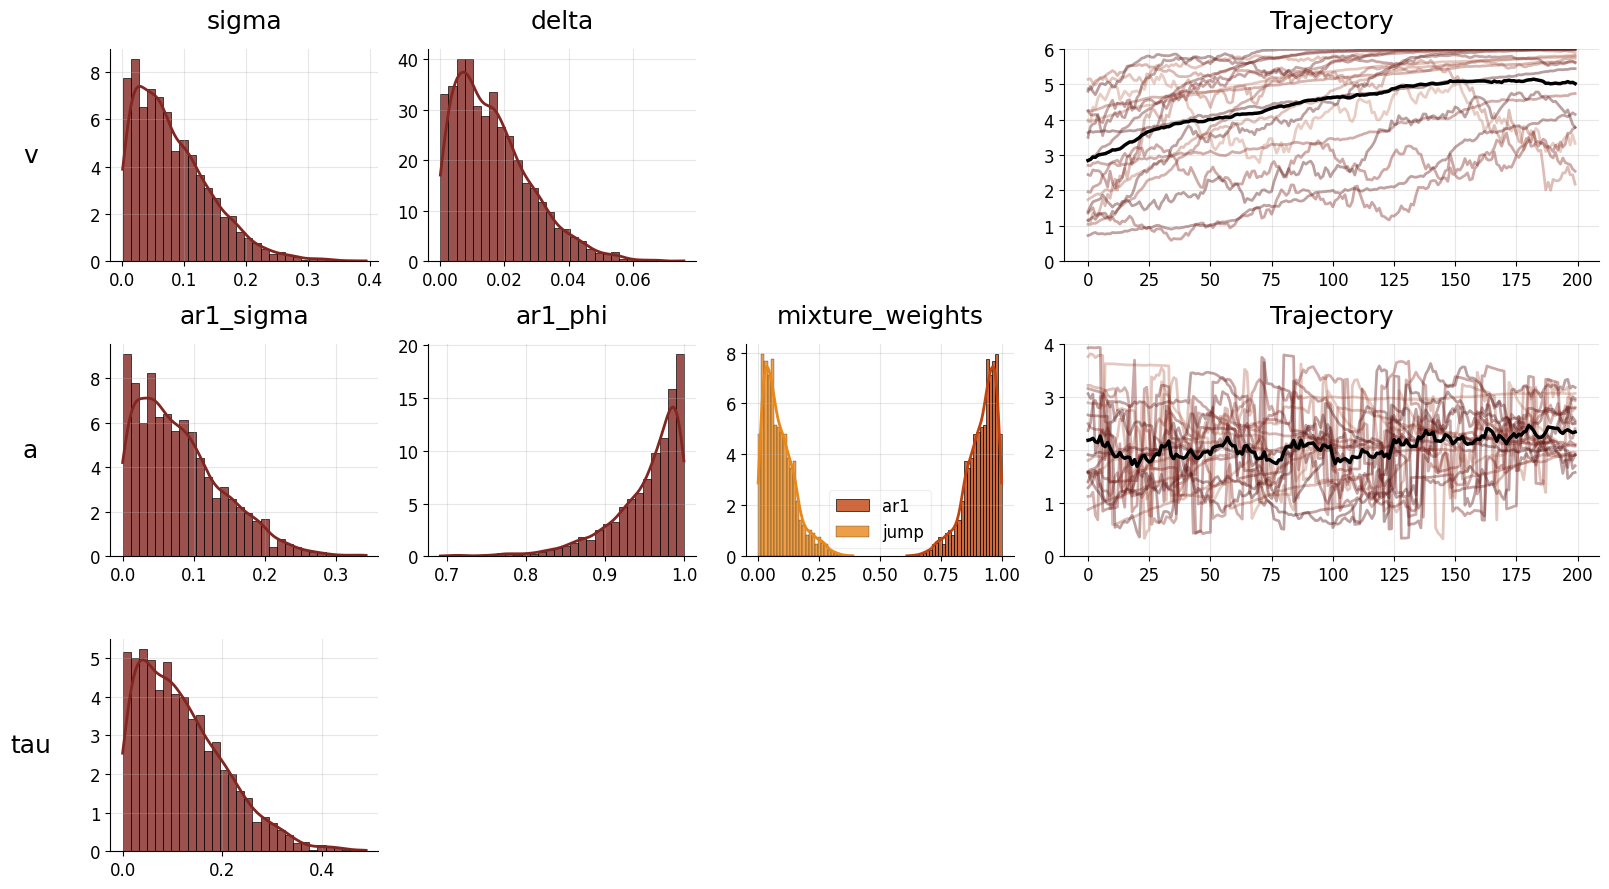

In [5]:
p = joint_prior.plot_joint_prior()

## Specify Generative Model

In [6]:
ddm = sup.simulation.sample_ddm

In [7]:
generative_model = sup.simulation.GenerativeModel(
    prior=joint_prior,
    model=ddm,
)

In [ ]:
# 6 individual trajectories for data dim 0
plot = generative_model.plot_push_forward(
    batch_size=6,
    steps=100,
    data_dim=0,
    type="trajectory",
)

# mean + 95% CI across 500 trajectories
plot = generative_model.plot_push_forward(
    batch_size=500,
    steps=100,
    data_dim=0,
    type="trajectory",
    aggregate=True,
)

# 6 individual RT distributions
plot = generative_model.plot_push_forward(
    batch_size=6,
    steps=200,
    data_dim=0,
    type="hist",
)

# distribution of mean RT across 1000 datasets (default stats_fun)
plot = generative_model.plot_push_forward(
    batch_size=1000,
    steps=200,
    data_dim=0,
    type="hist",
    aggregate=True,
)

# distribution of choice proportions across 1000 datasets (binary dim)
plot = generative_model.plot_push_forward(
    batch_size=1000,
    steps=200,
    data_dim=1,
    type="hist",
    aggregate=True,
    stats_fun=lambda x: x.mean(axis=-1)
)


## Specify Workflow

- Discuss workflow wrapper with Stefan

In [8]:
workflow = sup.workflow.Workflow(
    simulator=generative_model,
    checkpoint_filepath="network_test",
)

### Offline Training

In [ ]:
workflow.fit_offline(
    train_data_size=20,
    test_data_size=5,
    steps=100,
    epochs=2,
    batch_size=2
)

In [ ]:
plot = workflow.plot_history()

## Online Training

In [9]:
workflow.fit_online(
    steps=500,
    epochs=50,
    num_batches_per_epoch=500,
    batch_size=16
)

INFO:bayesflow:Fitting on dataset instance of OnlineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 62s 89ms/step - loss: -1.4034
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 42s 84ms/step - loss: -3.0375
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 45s 91ms/step - loss: -3.3568
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 46s 92ms/step - loss: -3.4338
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 46s 92ms/step - loss: -3.4595
Epoch 6/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 44s 89ms/step - loss: -3.4737
Epoch 7/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 47s 94ms/step - loss: -3.4806 
Epoch 8/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 47s 93ms/step - loss: -3.4858
Epoch 9/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 44s 87ms/step - loss: -3.4893
Epoch 10/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 43s 87ms/step - loss: -3.4907
Epoch 11/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 44s 87ms/step - loss: -3.5000
Epoch 12/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 44s 87ms/step - loss: -3.4976
Epoch 13/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 43s 85ms/step - loss: -3.5042
Epoch 14/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 42s 85ms/step - loss: -3.5006
Epoch 15/50
50

INFO:bayesflow:Training completed in 37.00 minutes.
INFO:bayesflow:Training is now finished.
You can find the trained approximator at 'network_test/model.keras'.
To load it, use approximator = keras.saving.load_model("network_test/model.keras").


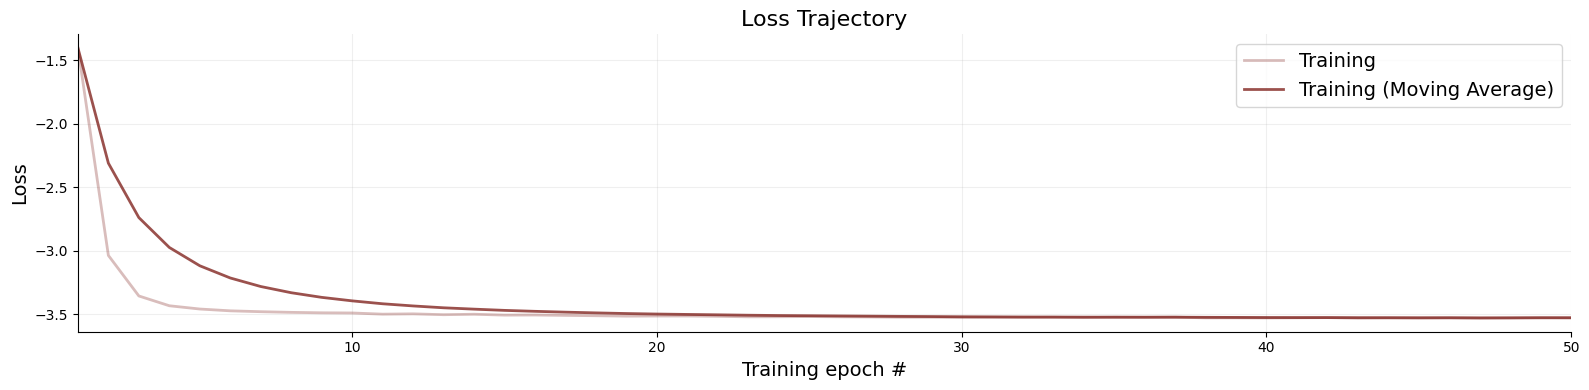

In [10]:
plot = workflow.plot_history()

## Validation

### Time-varying Parameters

In [15]:
import gc
jax.clear_caches()
gc.collect()

2693

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

/scicore/home/rieskamp/schuma0018/GitHub/superstats/examples/../superstats/diagnostics/plots/time_varying_validation.py:178: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


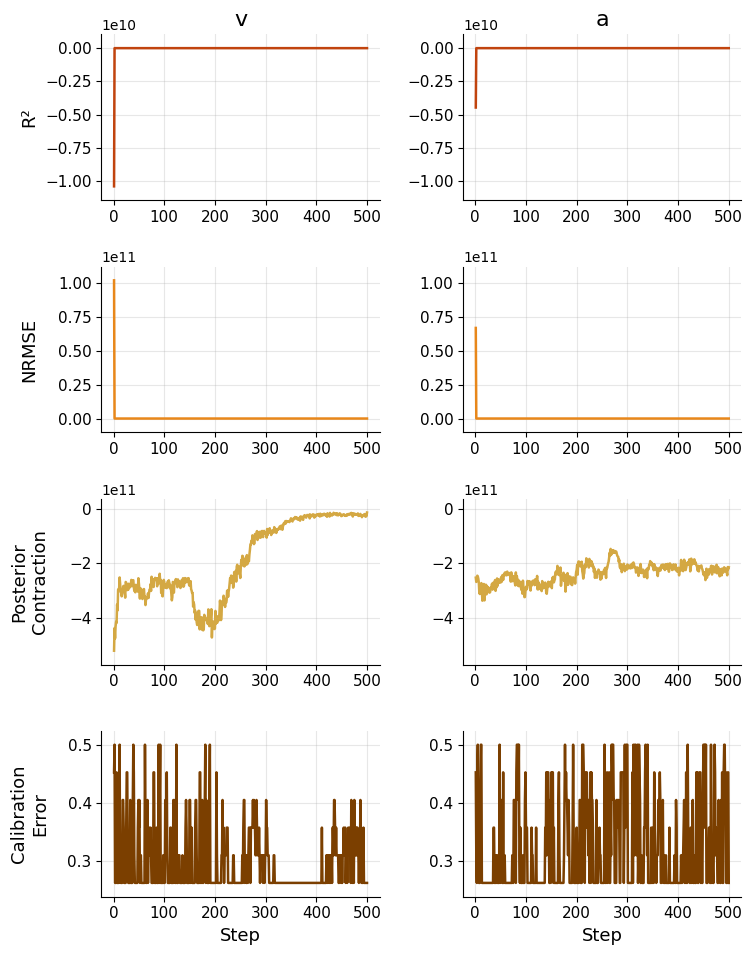

In [17]:
plot = workflow.validate_time_varying(
    steps=500,
    num_sims=1,
    num_samples=1000,
)

### Time-invariant Parameters

In [ ]:
fig_recovery, fig_calibration = workflow.validate_time_invariant(
    steps=500,
    num_sims=500,
    num_samples=500
)

## Data Fitting